In [1]:
# ===========================================================================================================================================
# ===========================================================================================================================================
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

from phase_space_reconstruction.virtual.beamlines import palxfel_Experiment
from phase_space_reconstruction.diagnostics import ImageDiagnostic
from phase_space_reconstruction.modeling import ImageDataset3D_EXP
from phase_space_reconstruction.train import train_3d_scan_palxfel_Experiment

from bmadx.plot import plot_projections
from bmadx.constants import PI
from bmadx.bmad_torch.track_torch import particle_to_beam

In [2]:
# Reference beam energy
p0c = 260.5E6 

In [3]:
# diagnostic beamline:
lattice_scm1, lattice_scm2 = palxfel_Experiment(p0c=p0c, dipole_on=True)

In [4]:
# Load the dataset
params     = torch.load('parameters.dset')
img_bc_off = torch.load('image_BC_OFF.dset')
img_bc_on  = torch.load('image_BC_ON.dset')

# Dataset configuration for GPSR process
dset = ImageDataset3D_EXP(params, img_bc_off, img_bc_on)


In [5]:
# Phase range of the X-band cavity used in the BmadX simulation
vs = -torch.linspace((131.5 + 90), (166.5+90), 8) * PI/180 / (2*PI)
print(vs)

tensor([-0.6153, -0.6292, -0.6431, -0.6569, -0.6708, -0.6847, -0.6986, -0.7125])


In [6]:
# =========================================================
# create diagnostic screen: 
#dsize = dset.images1.size()[2]
Xsize_SCM9 = len(dset.images2[0][0][0,:])
Ysize_SCM9 = len(dset.images2[0][0][:,0])


px_scale_SCM9 = 2.020724476018733e-05

binsx_SCM9 = torch.Tensor(np.arange(Xsize_SCM9) - (Xsize_SCM9 / 2)) * px_scale_SCM9
binsy_SCM9 = torch.Tensor(np.arange(Ysize_SCM9) - (Ysize_SCM9 / 2)) * px_scale_SCM9
bandwidth_SCM9x = (binsx_SCM9[1]-binsx_SCM9[0]) / 2
bandwidth_SCM9y = (binsy_SCM9[1]-binsy_SCM9[0]) / 2
print(bandwidth_SCM9x)
print(bandwidth_SCM9y)

screen2 = ImageDiagnostic(binsy_SCM9, binsx_SCM9, bandwidth_SCM9x)
resolution2 = bandwidth_SCM9x*2
print(resolution2)

tensor(1.0104e-05)
tensor(1.0104e-05)
tensor(2.0207e-05)


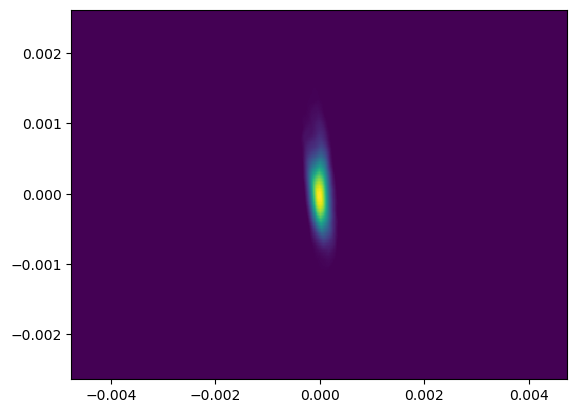

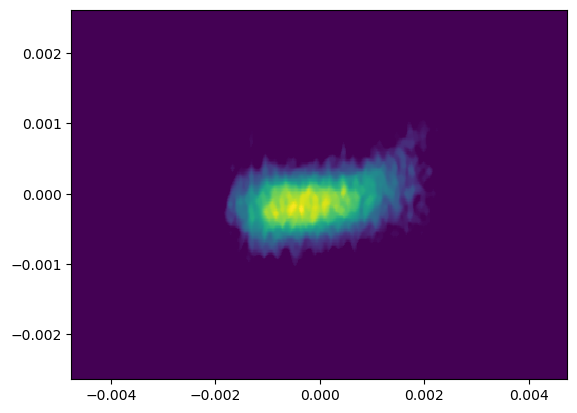

In [7]:
plt.figure()
plt.pcolor(binsy_SCM9, binsx_SCM9, (dset.images1[0][0].T))

plt.figure()
plt.pcolor(binsy_SCM9, binsx_SCM9, (dset.images2[0][0].T))


In [8]:
# Split the dataset
def split_2screen_dset(dset):
    n = dset.__len__()
    print(n)
    train_dset_params, train_dset_imgs1, train_dset_imgs2 = dset.__getitem__(np.arange(0, n, 2))
    train_dset = ImageDataset3D_EXP(train_dset_params, train_dset_imgs1, train_dset_imgs2)
    test_dset_params, train_dset_imgs1, train_dset_imgs2 = dset.__getitem__(np.arange(1, n, 2))
    test_dset = ImageDataset3D_EXP(test_dset_params, train_dset_imgs1, train_dset_imgs2)
    return train_dset, test_dset

train_dset, test_dset = split_2screen_dset(dset)
print(len(train_dset))
print(len(test_dset))

80
40
40


In [9]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.current_device())
print(torch.cuda.device(0))
print(torch.cuda.get_device_name(0))


True
2
0
NVIDIA RTX A6000


In [10]:
%%time
save_dir = './'
scan_ids = [0, 2, 4, 6, 8, 10, 14] 

pred_beam, model = train_3d_scan_palxfel_Experiment(
    train_dset, 
    lattice_scm1,
    lattice_scm2,
    p0c, 
    screen2, 
    screen2, 
    ids = scan_ids,
    n_epochs = 1_000,
    n_particles = 100_000,
    device = 'cuda',
    save_dir = save_dir,
    distribution_dump_frequency=200,
    distribution_dump_n_particles=500_000,
    use_decay=False,
    lr=0.01,
    )

Using device: cuda
0 tensor(2.7938e-05, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
50 tensor(5.9736e-06, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
100 tensor(5.3917e-06, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
150 tensor(3.7591e-06, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
200 tensor(3.8304e-06, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
250 tensor(4.3777e-06, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
300 tensor(4.4534e-06, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
350 tensor(3.9628e-06, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
400 tensor(5.0615e-06, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
450 tensor(2.9981e-06, device='cuda:0', dtype=torch.float64,
       grad_fn=<AddBackward0>)
500 tensor(3.7931e-06, device='cuda:0', dtype=torch.float64,
   

In [11]:
pred_beam.cpu()

Beam()

In [12]:
# generate and save train and test datasets
save_dir = os.path.join('./')
from phase_space_reconstruction.virtual.scans import run_palxfel_Experiment

recon_dset = run_palxfel_Experiment(
    pred_beam,
    lattice_scm1,
    lattice_scm2,
    screen2,
    train_dset.params,
    ids = scan_ids,
    save_as = os.path.join(save_dir, 'Predicted_images.dset')
    )




dataset saved as './Predicted_images.dset'


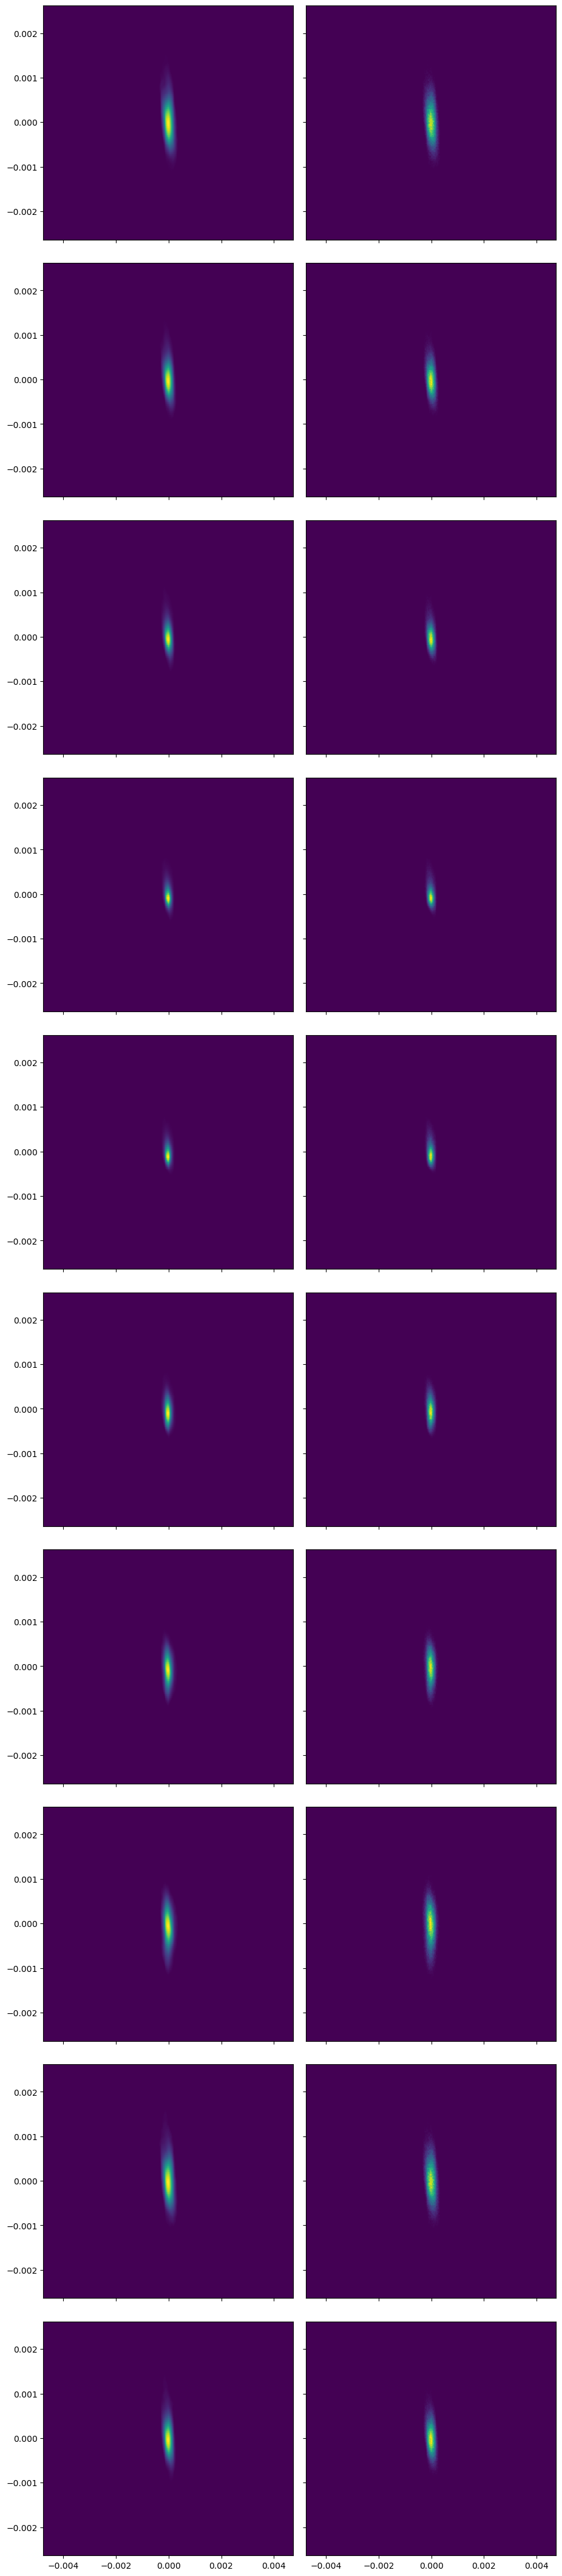

In [13]:

s = torch.arange(0,10,1).to(device='cuda')
fig,ax = plt.subplots(len(s),2,sharex="all", sharey="all", gridspec_kw={"hspace":0.1,"wspace":0.05,"right":0.97,"top":1.5,"bottom":0.1})
fig.set_size_inches(10,30)
for i in range(len(s)):
    ax[i][0].pcolor(binsy_SCM9, binsx_SCM9, (train_dset.images1[i][0].T))
    ax[i][1].pcolor(binsy_SCM9, binsx_SCM9, (recon_dset.images1[i][0].T))


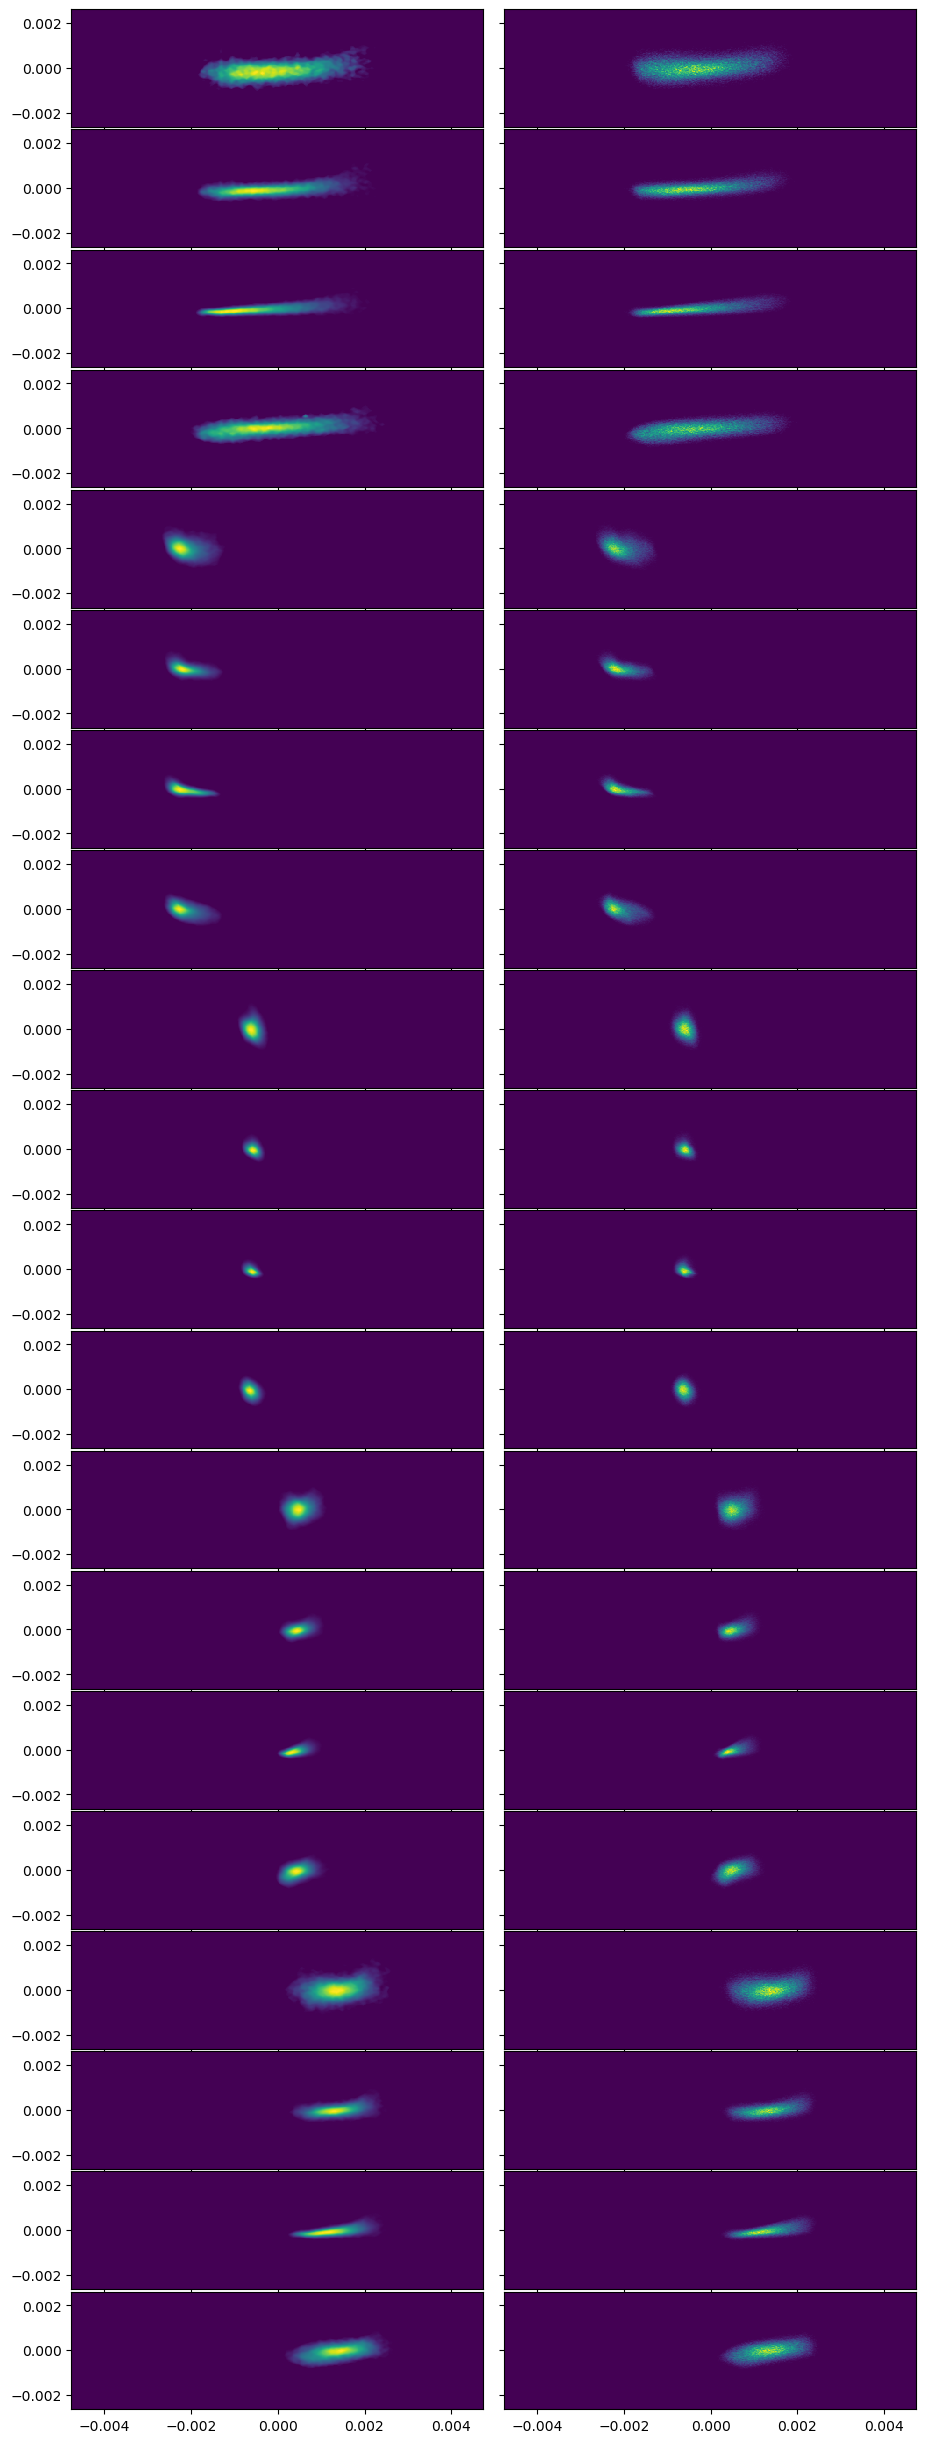

In [14]:

s = torch.arange(0,20,1).to(device='cuda')
fig,ax = plt.subplots(len(s),2,sharex="all", sharey="all", gridspec_kw={"hspace":0.02,"wspace":0.05,"right":0.97,"top":1.5,"bottom":0.7})
fig.set_size_inches(10,30)
for i in range(len(s)):
    ax[i][0].pcolor(binsy_SCM9, binsx_SCM9, (train_dset.images2[i*2][0].T))
    ax[i][1].pcolor(binsy_SCM9, binsx_SCM9, (recon_dset.images2[i*2][0].T))


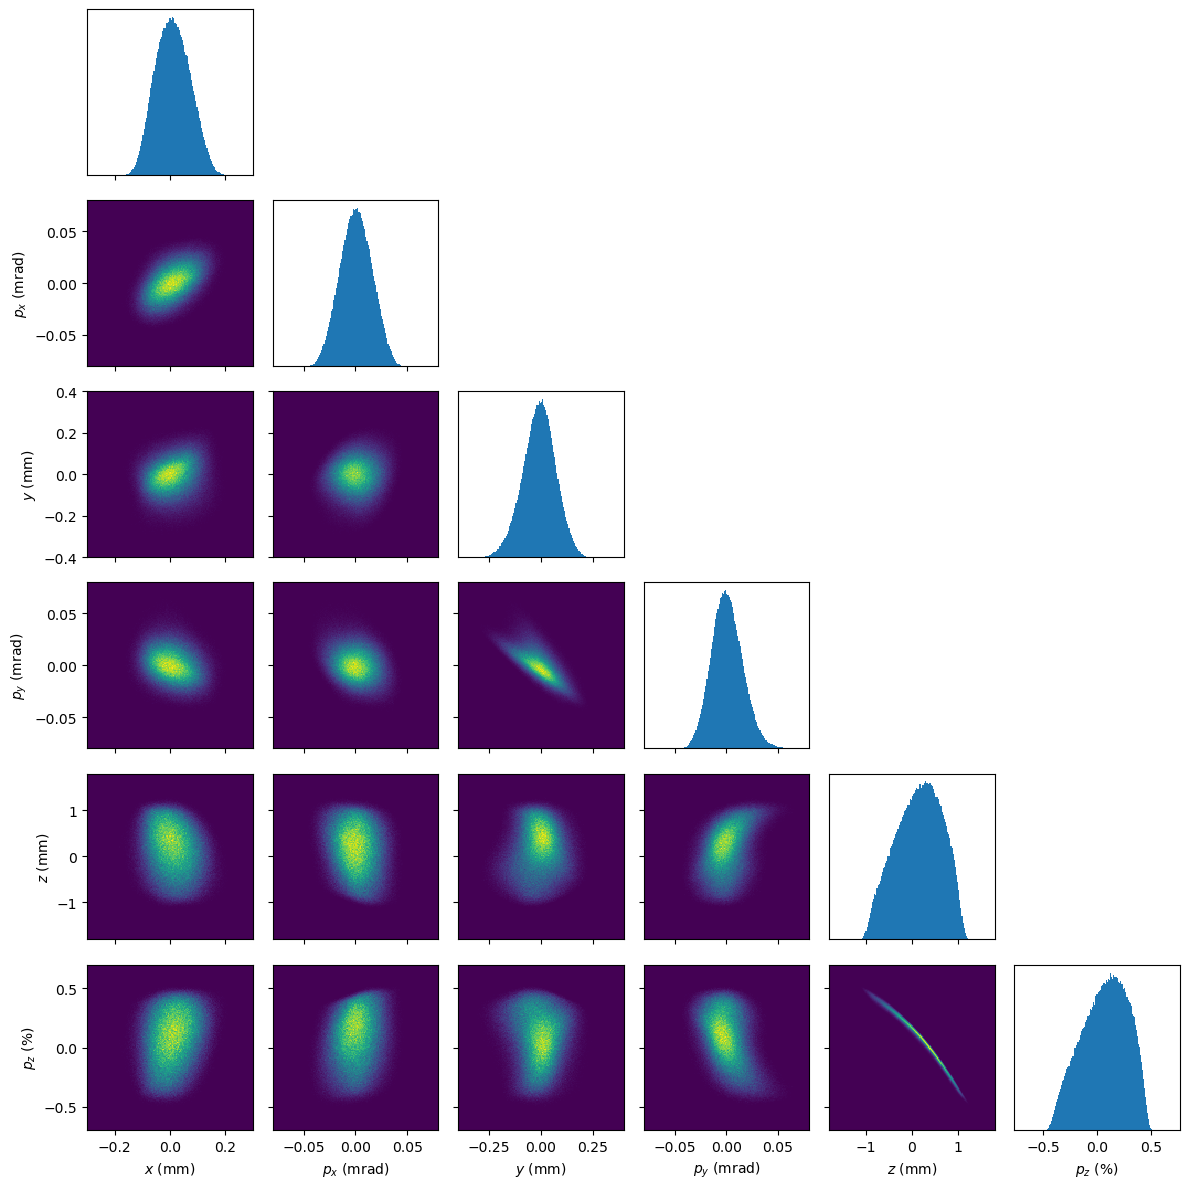

In [15]:
from bmadx.plot import plot_projections
#plot gt beam
pred_beam = torch.load('dist_1000.pt', weights_only=False)
lims = np.array([[-0.3e-3, 0.3e-3],
                 [-0.08e-3, 0.08e-3],
                 [-0.4e-3, 0.4e-3],
                 [-0.08e-3, 0.08e-3],
                 [-1.8e-3, 1.8e-3],
                 [-0.7e-2, 0.7e-2]])*1
fig, ax = plot_projections(
    pred_beam.numpy_particles(),
    custom_lims = lims,
    bins=150,
    background = 0
)

In [16]:
X  = pred_beam.x
xp = pred_beam.px
Y  = pred_beam.y
yp = pred_beam.py
Z  = pred_beam.z
delta = pred_beam.pz



In [17]:
torch.set_printoptions(precision=9)

emitx = torch.sqrt( torch.mean((X-torch.mean(X))**2)*torch.mean((xp-torch.mean(xp))**2) - torch.mean((X-torch.mean(X))*(xp-torch.mean(xp)))**2)
emity = torch.sqrt( torch.mean((Y-torch.mean(Y))**2)*torch.mean((yp-torch.mean(yp))**2) - torch.mean((Y-torch.mean(Y))*(yp-torch.mean(yp)))**2)
emitz = torch.sqrt( torch.mean((Z-torch.mean(Z))**2)*torch.mean((delta-torch.mean(delta))**2) - torch.mean((Z-torch.mean(Z))*(delta-torch.mean(delta)))**2)

# Normalized emittance
enx = emitx * (p0c/0.511e6)
eny = emity * (p0c/0.511e6)
enz = emitz * (p0c/0.511e6)

sigx = torch.sqrt( torch.mean( ((X - torch.mean(X))**2 )))
sigy = torch.sqrt( torch.mean( ((Y - torch.mean(Y))**2 )))
sigz = torch.sqrt( torch.mean( ((Z - torch.mean(Z))**2 )))

# =====================================================================
# =====================================================================
# Linear Twiss parameters from this setting
betax = (sigx**2) / emitx # since sigx is in mm unit
betay = (sigy**2) / emity

alphax= - (torch.mean((X-torch.mean(X))*(xp-torch.mean(xp)))) / emitx
alphay= - (torch.mean((Y-torch.mean(Y))*(yp-torch.mean(yp)))) / emity

print(enx)
print(eny)
print(enz)
print(sigx)
print(sigy)
print(sigz)

print("========")

print(betax)
print(betay)
print(alphax)
print(alphay)


tensor(4.129972524e-07)
tensor(4.070633395e-07)
tensor(8.137926488e-05)
tensor(6.081320316e-05)
tensor(7.811230898e-05)
tensor(0.000490807)
tensor(4.564943790)
tensor(7.641239166)
tensor(-0.529490411)
tensor(1.052299261)
